In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

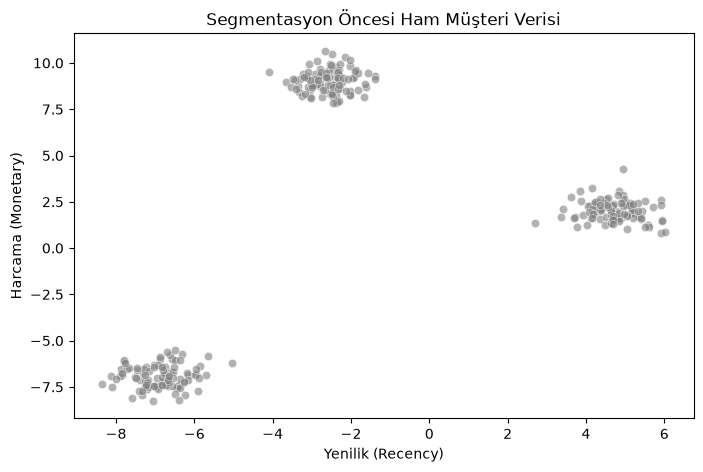

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs

# 300 müşterilik, 2 özellikli sentetik veri üretiyoruz.
X_ham, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.60, random_state=42)
df = pd.DataFrame(X_ham, columns=['Yenilik (Recency)', 'Harcama (Monetary)'])

plt.figure(figsize=(8, 5))
sns.scatterplot(x='Yenilik (Recency)', y='Harcama (Monetary)', data=df, color='gray', alpha=0.6)
plt.title('Segmentasyon Öncesi Ham Müşteri Verisi')
plt.show()

In [3]:
scaler = StandardScaler()
X_olcekli = scaler.fit_transform(df)

# K=3
kmeans = KMeans(n_clusters=3, random_state=42)

# Gözetimsiz öğrenmede cevap anahtarı (y) olmadığı için doğrudan verinin kendini veriyoruz
df['Segment'] = kmeans.fit_predict(X_olcekli)

# 4. Centroids
merkezler = kmeans.cluster_centers_

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


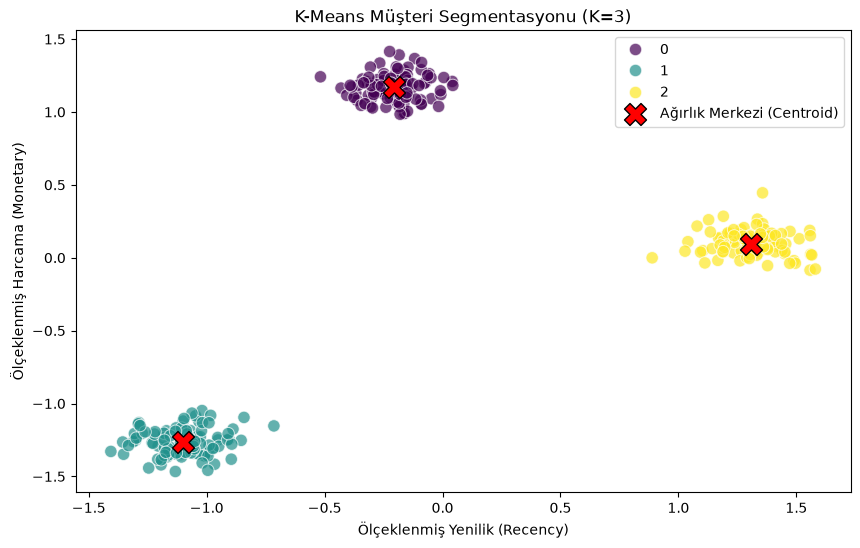

In [4]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_olcekli[:, 0], 
    y=X_olcekli[:, 1], 
    hue=df['Segment'], 
    palette='viridis', 
    s=80, 
    alpha=0.7
)

plt.scatter(
    merkezler[:, 0], 
    merkezler[:, 1], 
    c='red', 
    s=250, 
    marker='X', 
    label='Ağırlık Merkezi (Centroid)',
    edgecolor='black'
)

plt.title('K-Means Müşteri Segmentasyonu (K=3)')
plt.xlabel('Ölçeklenmiş Yenilik (Recency)')
plt.ylabel('Ölçeklenmiş Harcama (Monetary)')
plt.legend()
plt.show()

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Window

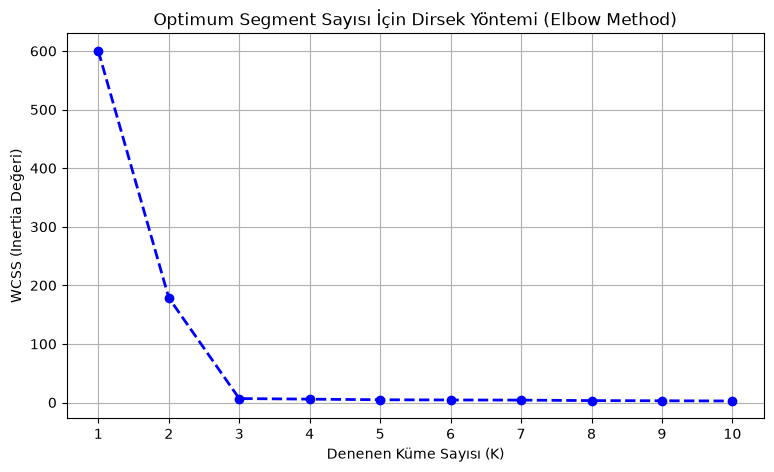

In [5]:
wcss = []

# K değerlerini 1'den 10'a kadar sırayla deniyoruz
for i in range(1, 11):
    kmeans_deneme = KMeans(n_clusters=i, random_state=42)
    kmeans_deneme.fit(X_olcekli)
    # Her denemede ortaya çıkan WCSS değerini (inertia_) listeye ekliyoruz
    wcss.append(kmeans_deneme.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b', linewidth=2)
plt.title('Optimum Segment Sayısı İçin Dirsek Yöntemi (Elbow Method)')
plt.xlabel('Denenen Küme Sayısı (K)')
plt.ylabel('WCSS (Inertia Değeri)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()